In [1]:
from wavelet_class import *

import pandas as pd
import xarray as xr
import numpy as np

In [2]:
series = pd.read_csv("~/signal-extraction/results/mimoae_base/mimoae_base_extractr_results_latent.csv")

series = series.set_index('time')

series.index = pd.to_datetime(series.index)

print(type(series.index))

<class 'pandas.core.indexes.datetimes.DatetimeIndex'>


In [3]:
wa = WaveletAnalyzer(WaveletConfig(dt=1/12, dj=0.025))

In [4]:
wlt = wa.cwt(series['latent'])

In [5]:
wlt_red = wa.confidence_interval(wlt, series['latent'], conf=0.95, noise_type="r")

Red Noise AR1 Coefficient: 0.9894779934063982


In [6]:
recon, sig_scales = wa.reconstruct(wlt_red, series['latent'])

Significant scales (within COI):
[ 0.17  0.17  0.17  0.18  0.18  0.18  0.18  0.19  0.19  0.2   0.2   0.21
  0.21  0.21  0.22  0.22  0.22  0.23  0.23  0.24  0.24  0.25  0.25  0.26
  0.26  0.27  0.27  0.28  0.28  0.29  0.29  0.3   0.3   0.31  0.31  0.32
  0.33  0.33  0.34  0.35  0.35  0.36  0.36  0.37  0.38  0.38  0.39  0.4
  0.4   0.41  0.42  0.42  0.43  0.44  0.45  0.46  0.46  0.47  0.5   0.51
  0.51  0.52  0.53  0.54  0.55  0.56  0.57  0.58  0.59  0.6   0.61  0.62
  0.63  0.64  0.66  0.67  0.68  0.69  0.7   0.71  0.73  0.74  0.75  0.77
  0.78  0.79  0.81  0.82  0.84  0.85  0.86  0.88  0.9   0.91  0.93  0.94
  0.96  0.98  0.99  1.01  1.03  1.05  1.06  1.08  1.1   1.12  1.14  1.16
  1.18  1.2   1.22  1.24  1.27  1.29  1.31  1.33  1.36  1.38  1.4   1.43
  1.45  1.48  1.51  1.53  1.56  1.59  1.61  1.64  1.67  1.7   1.73  1.76
  1.79  1.82  1.85  1.89  1.92  1.95  1.99  2.02  2.06  2.09  2.13  2.17
  2.2   2.24  2.28  2.32  2.36  2.4   2.45  2.49  2.53  2.58  2.62  2.67
  2.71  2.76  2.81 

dc = pd.read_csv("~/signal-extraction/vae_input_data/AR_cfs.csv")
dc['time'] = pd.to_datetime(dc['time'])

dc = dc.set_index('time')
dc

Processing latent ...
Red Noise AR1 Coefficient: 0.9894779934063982


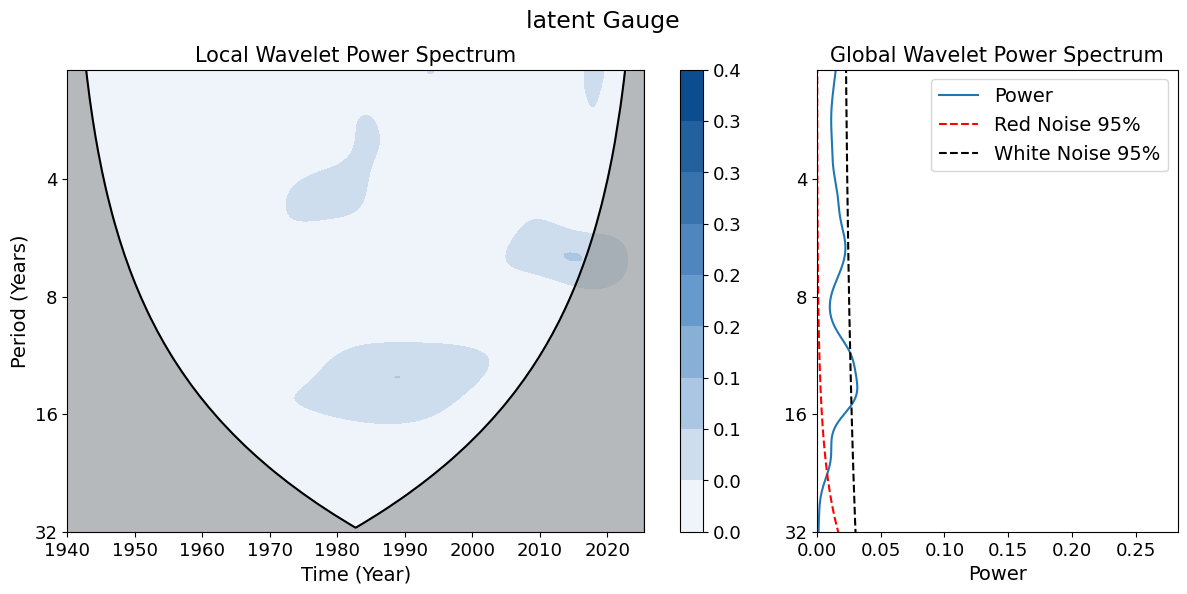

Red Noise Sig Test Results
Significant scales (within COI):
[ 0.17  0.17  0.17  0.18  0.18  0.18  0.18  0.19  0.19  0.2   0.2   0.21
  0.21  0.21  0.22  0.22  0.22  0.23  0.23  0.24  0.24  0.25  0.25  0.26
  0.26  0.27  0.27  0.28  0.28  0.29  0.29  0.3   0.3   0.31  0.31  0.32
  0.33  0.33  0.34  0.35  0.35  0.36  0.36  0.37  0.38  0.38  0.39  0.4
  0.4   0.41  0.42  0.42  0.43  0.44  0.45  0.46  0.46  0.47  0.5   0.51
  0.51  0.52  0.53  0.54  0.55  0.56  0.57  0.58  0.59  0.6   0.61  0.62
  0.63  0.64  0.66  0.67  0.68  0.69  0.7   0.71  0.73  0.74  0.75  0.77
  0.78  0.79  0.81  0.82  0.84  0.85  0.86  0.88  0.9   0.91  0.93  0.94
  0.96  0.98  0.99  1.01  1.03  1.05  1.06  1.08  1.1   1.12  1.14  1.16
  1.18  1.2   1.22  1.24  1.27  1.29  1.31  1.33  1.36  1.38  1.4   1.43
  1.45  1.48  1.51  1.53  1.56  1.59  1.61  1.64  1.67  1.7   1.73  1.76
  1.79  1.82  1.85  1.89  1.92  1.95  1.99  2.02  2.06  2.09  2.13  2.17
  2.2   2.24  2.28  2.32  2.36  2.4   2.45  2.49  2.53  2.58  2.6

In [7]:
df_out, sig_scales_all = wa.process_dataframe_columns(
    df=series,
    cols=['latent'],
    siglvl=0.95,
    sigtest="default",   # "red", "white", or "default"
    plot_wave=True,      # show local+global spectrum plots
)

### Trying with discharge

In [8]:
dc = pd.read_csv("~/signal-extraction/vae_input_data/AR_cfs.csv")
dc['time'] = pd.to_datetime(dc['time'])

dc = dc.set_index('time')
dc

,cfs
time,
1940-01-31,24300.0
1940-02-29,57500.0
1940-03-31,69600.0
1940-04-30,29800.0
1940-05-31,11300.0
...,...
2025-02-28,7730.0
2025-03-31,6400.0
2025-04-30,7480.0


Processing cfs ...
Red Noise AR1 Coefficient: 0.5590070924795306


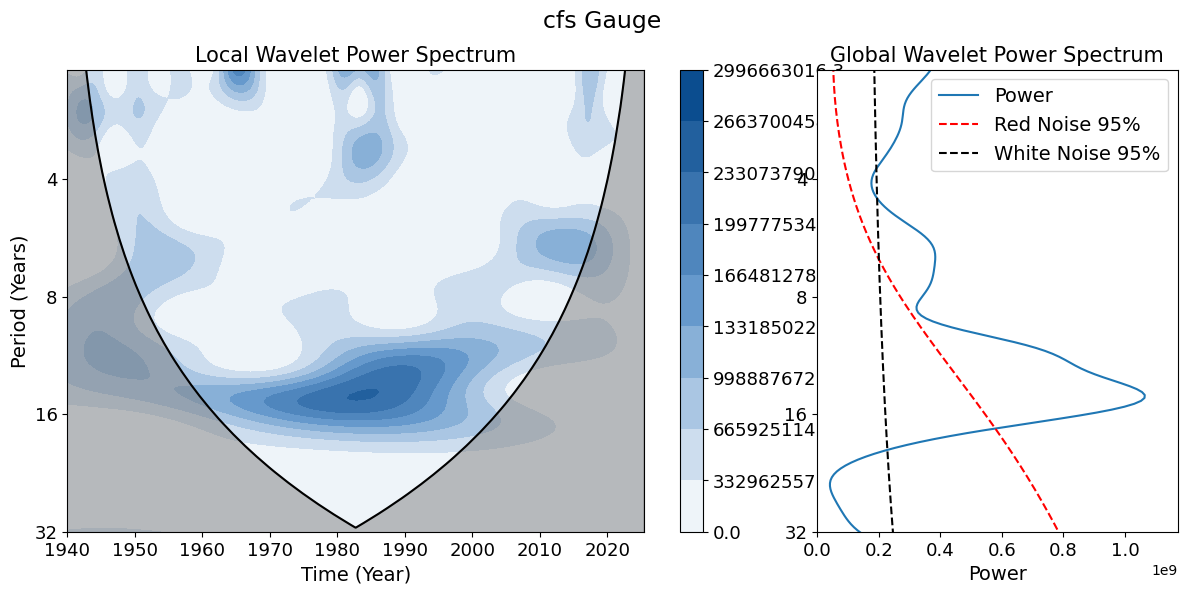

Red Noise Sig Test Results
Significant scales (within COI):
[ 0.17  0.18  0.18  0.18  0.21  0.21  0.21  0.22  0.22  0.22  0.26  0.27
  0.27  0.28  0.28  0.29  0.29  0.3   0.35  0.36  0.36  0.37  0.38  0.38
  0.39  0.4   0.4   0.41  0.42  0.42  0.43  0.44  0.53  0.54  0.55  0.56
  0.57  0.58  0.59  0.6   0.61  0.62  0.63  0.64  0.66  0.67  0.68  0.69
  0.7   0.71  0.73  0.74  0.75  0.77  0.78  0.79  0.81  0.82  0.84  0.85
  0.86  0.88  0.9   0.91  0.93  1.01  1.03  1.05  1.06  1.08  1.1   1.12
  1.14  1.16  1.18  1.2   1.22  1.24  1.27  1.29  1.31  1.33  1.36  1.38
  1.4   1.43  1.45  1.48  1.51  1.53  1.56  1.59  1.61  1.64  1.67  1.7
  1.73  1.76  1.79  1.82  1.85  1.89  1.92  1.95  1.99  2.02  2.06  2.09
  2.13  2.17  2.2   2.24  2.28  2.32  2.36  2.4   2.45  2.49  2.53  2.58
  2.62  2.67  2.71  2.76  2.81  2.86  2.91  2.96  3.01  3.06  3.12  3.17
  3.23  3.28  3.34  3.4   3.46  3.52  3.58  3.64  3.71  3.77  3.84  3.9
  3.97  4.04  4.11  4.18  4.26  4.33  4.41  4.48  4.56  4.64  4.72

In [9]:
dc_out, dc_sig_scales_all = wa.process_dataframe_columns(
    df=dc,
    cols=['cfs'],
    siglvl=0.95,
    sigtest="default",   # "red", "white", or "default"
    plot_wave=True,      # show local+global spectrum plots
)

Processing cfs_wave ...
Red Noise AR1 Coefficient: 0.7943027612574619


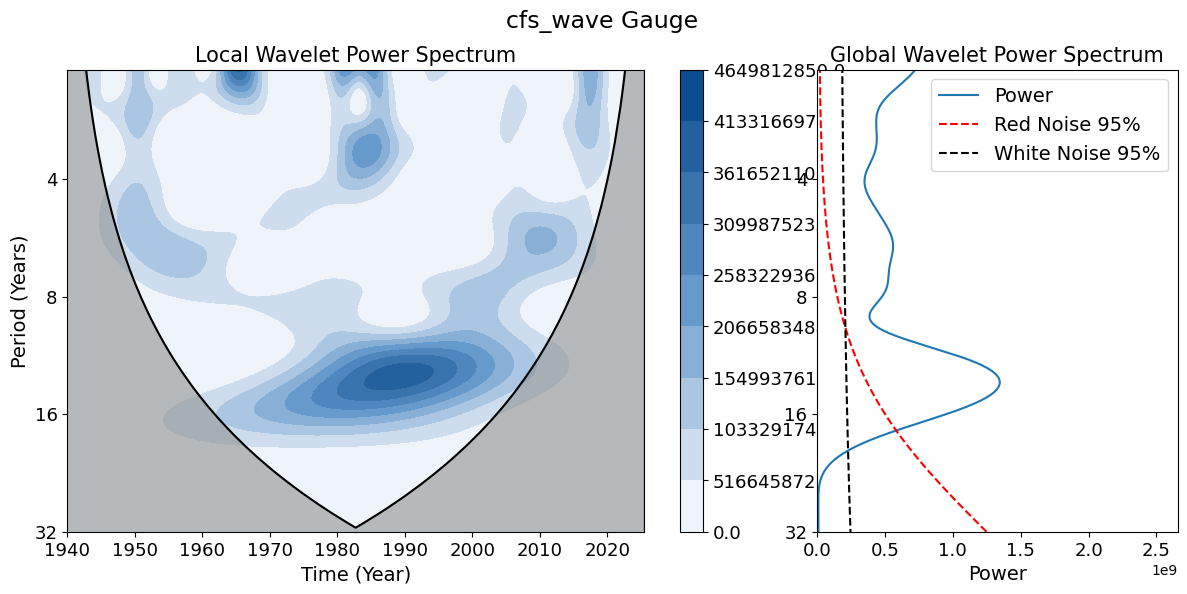

Red Noise Sig Test Results
Significant scales (within COI):
[ 0.21  0.21  0.22  0.22  0.22  0.26  0.27  0.27  0.28  0.28  0.29  0.29
  0.3   0.3   0.35  0.35  0.36  0.36  0.37  0.38  0.38  0.39  0.4   0.4
  0.41  0.42  0.42  0.43  0.44  0.45  0.52  0.53  0.54  0.55  0.56  0.57
  0.58  0.59  0.6   0.61  0.62  0.63  0.64  0.66  0.67  0.68  0.69  0.7
  0.71  0.73  0.74  0.75  0.77  0.78  0.79  0.81  0.82  0.84  0.85  0.86
  0.88  0.9   0.91  0.93  1.01  1.03  1.05  1.06  1.08  1.1   1.12  1.14
  1.16  1.18  1.2   1.22  1.24  1.27  1.29  1.31  1.33  1.36  1.38  1.4
  1.43  1.45  1.48  1.51  1.53  1.56  1.59  1.61  1.64  1.67  1.7   1.73
  1.76  1.79  1.82  1.85  1.89  1.92  1.95  1.99  2.02  2.06  2.09  2.13
  2.17  2.2   2.24  2.28  2.32  2.36  2.4   2.45  2.49  2.53  2.58  2.62
  2.67  2.71  2.76  2.81  2.86  2.91  2.96  3.01  3.06  3.12  3.17  3.23
  3.28  3.34  3.4   3.46  3.52  3.58  3.64  3.71  3.77  3.84  3.9   3.97
  4.04  4.11  4.18  4.26  4.33  4.41  4.48  4.56  4.64  4.72  4.81 

In [10]:
dc_out, dc_sig_scales_all = wa.process_dataframe_columns(
    df=dc_out,
    cols=['cfs_wave'],
    siglvl=0.95,
    sigtest="default",   # "red", "white", or "default"
    plot_wave=True,      # show local+global spectrum plots
)

<Axes: xlabel='time'>

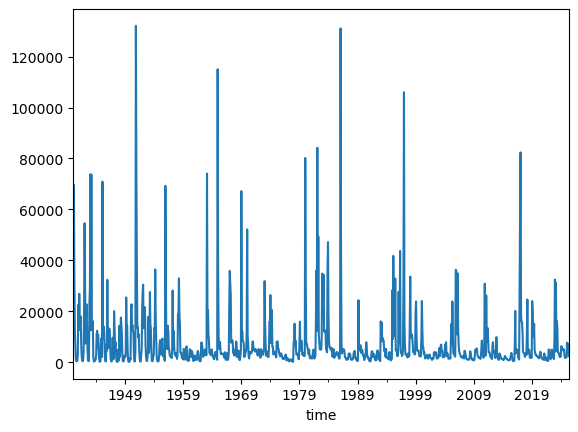

In [10]:
dc_out['cfs'].plot()

In [11]:
dc_out

,cfs,cfs_wave,cfs_wave_lag
time,,,
1940-01-31,24300.0,7579.298649,NaN
1940-02-29,57500.0,7579.298649,7579.298649
1940-03-31,69600.0,7948.600806,7579.298649
1940-04-30,29800.0,5106.225304,7948.600806
1940-05-31,11300.0,6390.158042,5106.225304
...,...,...,...
2025-02-28,7730.0,8339.255283,6769.680061
2025-03-31,6400.0,6912.622754,8339.255283
2025-04-30,7480.0,7649.299300,6912.622754


<Axes: xlabel='time'>

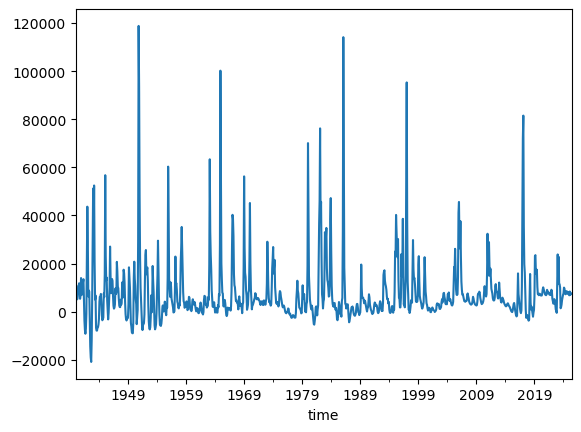

In [12]:
dc_out['cfs_wave'].plot()

Note that the wavelet reconstructed streamflow is nonphysical, showing negative values. 